In [1]:
# Import required libraries
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load your dataset
# Update the file path to your data file
file_path = 'C:\Users\DeelakaD\OneDrive - MAS Holdings (Pvt) Ltd\Documents\GitHub\Preventing-Mechanism\PreProcessing\MBP ControllerData 0521760 Overlock.xlsx'
all_data_file = r"C:\Users\DeelakaD\OneDrive - MAS Holdings (Pvt) Ltd\Documents\GitHub\Preventing-Mechanism\PreProcessing\MBP ControllerData 0521760 Overlock.xlsx"
breakdown_file = r"C:\Users\DeelakaD\OneDrive - MAS Holdings (Pvt) Ltd\Documents\GitHub\Preventing-Mechanism\PreProcessing\Synthetic Overlock Breakdowns.xlsx"

# Read the Excel file
df = pd.read_excel(file_path)

# Display first few rows and info
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Dataset shape: (1608, 19)

First few rows:
       Id  machineRPM                                   machineVibration  \
0  276344           0  10,172,20,180,30,143,40,162,50,147,60,151,70,1...   
1  276345           0  10,171,20,858,30,1506,40,805,50,832,60,539,70,...   
2  276347           0  10,846,20,767,30,958,40,8349,50,2720,60,1213,7...   
3  276348           0  10,182,20,783,30,515,40,278,50,74,60,33,70,260...   
4  276349           0  10,1441,20,1280,30,1482,40,4719,50,4342,60,391...   

   needleRuntime                dateTime  machineSerialNumber   status  \
0            892 2026-02-19 06:18:12.292               521760  Running   
1            788 2026-02-19 06:19:19.784               521760  Running   
2           3713 2026-02-19 06:19:47.941               521760  Running   
3            420 2026-02-19 06:19:53.744               521760  Running   
4           2801 2026-02-19 06:20:00.208               521760  Running   

   machineVoltageMean  machineVoltageMin  machineVoltag

In [3]:
# Data preprocessing for Prophet
# Prophet requires columns named 'ds' (datetime) and 'y' (value to forecast)

# Identify the date column and value column
# Adjust these based on your actual column names
date_column = df.columns[0]  # Assuming first column is date
value_column = df.columns[1]  # Assuming second column is the metric to forecast

# Create a dataframe for Prophet
prophet_df = pd.DataFrame({
    'ds': pd.to_datetime(df[date_column]),
    'y': pd.to_numeric(df[value_column], errors='coerce')
})

# Remove any NaN values
prophet_df = prophet_df.dropna()

# Sort by date
prophet_df = prophet_df.sort_values('ds').reset_index(drop=True)

print(f"Data prepared for Prophet")
print(f"Date range: {prophet_df['ds'].min()} to {prophet_df['ds'].max()}")
print(f"Number of records: {len(prophet_df)}")
print(f"Value range: {prophet_df['y'].min():.2f} to {prophet_df['y'].max():.2f}")
print("\nProcessed data sample:")
print(prophet_df.head())

Data prepared for Prophet
Date range: 1970-01-01 00:00:00.000276344 to 1970-01-01 00:00:00.000279013
Number of records: 1608
Value range: 0.00 to 0.00

Processed data sample:
                             ds  y
0 1970-01-01 00:00:00.000276344  0
1 1970-01-01 00:00:00.000276345  0
2 1970-01-01 00:00:00.000276347  0
3 1970-01-01 00:00:00.000276348  0
4 1970-01-01 00:00:00.000276349  0


In [4]:
# Split data into training and testing sets (80-20 split)
train_size = int(len(prophet_df) * 0.8)
train_df = prophet_df[:train_size]
test_df = prophet_df[train_size:]

print(f"Training set size: {len(train_df)} records")
print(f"Testing set size: {len(test_df)} records")

# Initialize and train the Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95,  # 95% confidence interval
    changepoint_prior_scale=0.05
)

# Add additional regressors if needed (optional)
# model.add_regressor('additional_column')

# Fit the model on training data
print("\nTraining Prophet model...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model.fit(train_df)
print("Model training completed!")

# Make predictions on test period
future = prophet_df[['ds']].copy()
forecast = model.predict(future)

# Extract predictions for test set
test_forecast = forecast[forecast['ds'].isin(test_df['ds'])].copy()

print(f"\nForecast summary:")
print(test_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

Training set size: 1286 records
Testing set size: 322 records

Training Prophet model...
Model training completed!

Forecast summary:
                                ds  yhat    yhat_lower    yhat_upper
1286 1970-01-01 00:00:00.000278686   0.0 -1.902784e-09  1.856980e-09
1287 1970-01-01 00:00:00.000278687   0.0 -1.870631e-09  1.856011e-09
1288 1970-01-01 00:00:00.000278688   0.0 -2.002301e-09  1.953832e-09
1289 1970-01-01 00:00:00.000278689   0.0 -2.069855e-09  1.941083e-09
1290 1970-01-01 00:00:00.000278690   0.0 -2.074644e-09  1.901467e-09


In [5]:
# Model evaluation
# Get actual values from test set
test_df_copy = test_df.copy()
test_df_copy = test_df_copy.reset_index(drop=True)

# Match predictions with actual values
predictions = test_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].reset_index(drop=True)
predictions = predictions.merge(test_df_copy, on='ds', how='inner')

# Calculate error metrics
mae = mean_absolute_error(predictions['y'], predictions['yhat'])
rmse = np.sqrt(mean_squared_error(predictions['y'], predictions['yhat']))
mape = np.mean(np.abs((predictions['y'] - predictions['yhat']) / predictions['y'])) * 100
r_squared = 1 - (np.sum((predictions['y'] - predictions['yhat'])**2) / 
                  np.sum((predictions['y'] - predictions['y'].mean())**2))

print("=" * 50)
print("MODEL PERFORMANCE METRICS (Test Set)")
print("=" * 50)
print(f"Mean Absolute Error (MAE):        {mae:.4f}")
print(f"Root Mean Squared Error (RMSE):   {rmse:.4f}")
print(f"Mean Absolute Percentage Error:   {mape:.2f}%")
print(f"R² Score:                         {r_squared:.4f}")
print("=" * 50)

# Show sample predictions vs actual
print("\nSample Predictions vs Actual Values:")
print(predictions[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']].head(10).to_string(index=False))

MODEL PERFORMANCE METRICS (Test Set)
Mean Absolute Error (MAE):        0.0000
Root Mean Squared Error (RMSE):   0.0000
Mean Absolute Percentage Error:   nan%
R² Score:                         nan

Sample Predictions vs Actual Values:
                           ds  y  yhat    yhat_lower   yhat_upper
1970-01-01 00:00:00.000278686  0   0.0 -1.902784e-09 1.856980e-09
1970-01-01 00:00:00.000278687  0   0.0 -1.870631e-09 1.856011e-09
1970-01-01 00:00:00.000278688  0   0.0 -2.002301e-09 1.953832e-09
1970-01-01 00:00:00.000278689  0   0.0 -2.069855e-09 1.941083e-09
1970-01-01 00:00:00.000278690  0   0.0 -2.074644e-09 1.901467e-09
1970-01-01 00:00:00.000278691  0   0.0 -1.922326e-09 1.857675e-09
1970-01-01 00:00:00.000278692  0   0.0 -1.893767e-09 1.907397e-09
1970-01-01 00:00:00.000278693  0   0.0 -1.927765e-09 2.018809e-09
1970-01-01 00:00:00.000278694  0   0.0 -1.884904e-09 1.986130e-09
1970-01-01 00:00:00.000278695  0   0.0 -1.989421e-09 1.921718e-09


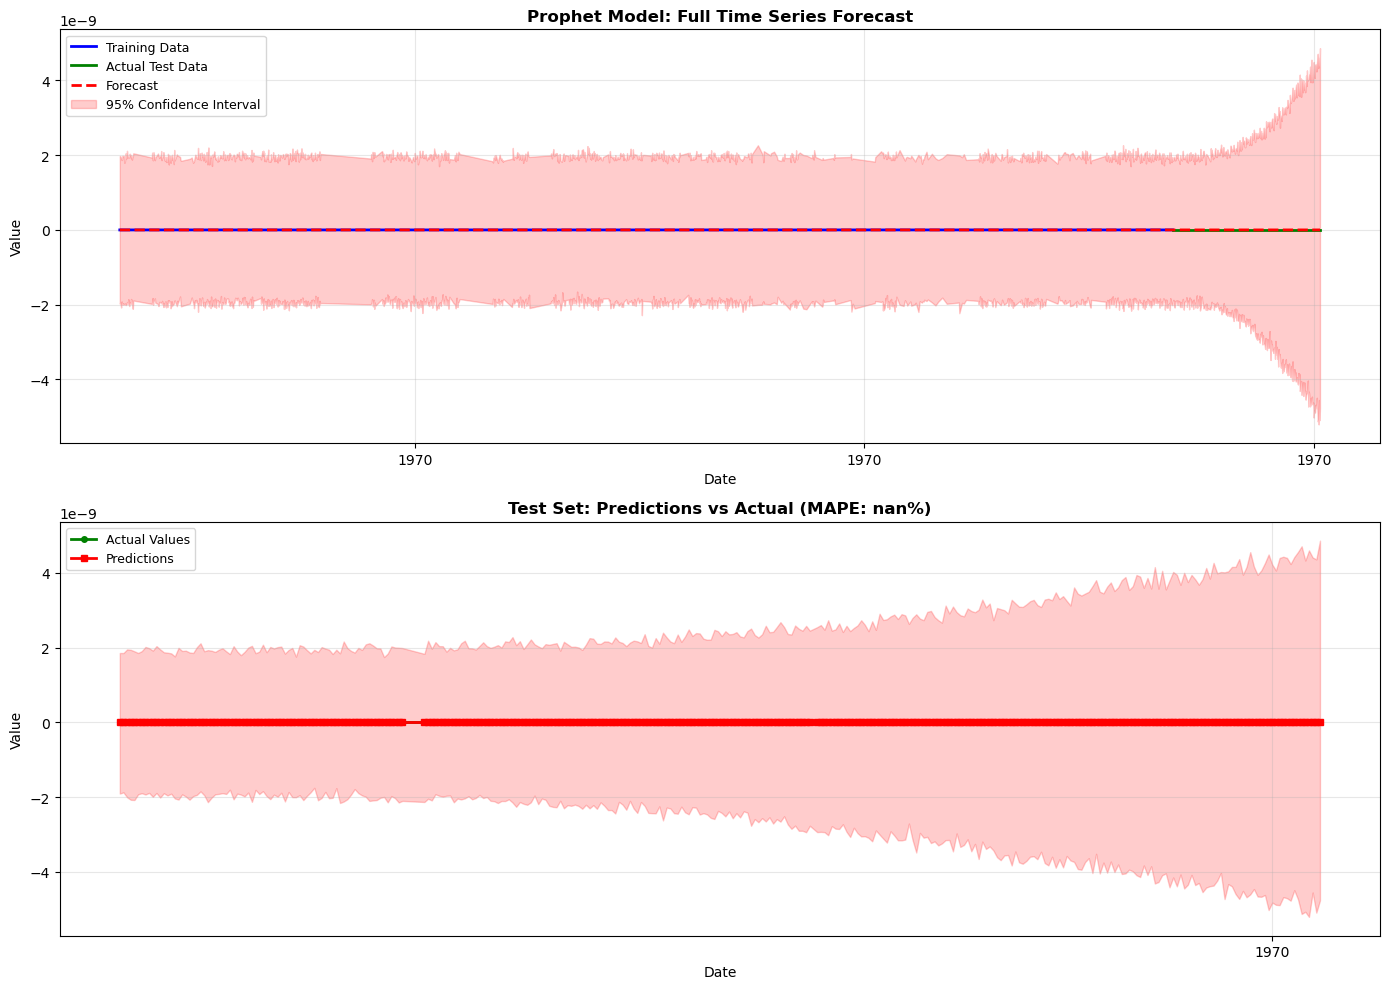

In [6]:
# Visualization of results
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Full forecast with actual data
ax1 = axes[0]
ax1.plot(train_df['ds'], train_df['y'], label='Training Data', color='blue', linewidth=2)
ax1.plot(test_df['ds'], test_df['y'], label='Actual Test Data', color='green', linewidth=2)
ax1.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='red', linewidth=2, linestyle='--')
ax1.fill_between(forecast['ds'], 
                  forecast['yhat_lower'], 
                  forecast['yhat_upper'], 
                  alpha=0.2, color='red', label='95% Confidence Interval')
ax1.set_xlabel('Date', fontsize=10)
ax1.set_ylabel('Value', fontsize=10)
ax1.set_title('Prophet Model: Full Time Series Forecast', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Prediction vs Actual (test set only)
ax2 = axes[1]
ax2.plot(predictions['ds'], predictions['y'], marker='o', label='Actual Values', 
         color='green', linewidth=2, markersize=4)
ax2.plot(predictions['ds'], predictions['yhat'], marker='s', label='Predictions', 
         color='red', linewidth=2, markersize=4)
ax2.fill_between(predictions['ds'], 
                  predictions['yhat_lower'], 
                  predictions['yhat_upper'], 
                  alpha=0.2, color='red')
ax2.set_xlabel('Date', fontsize=10)
ax2.set_ylabel('Value', fontsize=10)
ax2.set_title(f'Test Set: Predictions vs Actual (MAPE: {mape:.2f}%)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

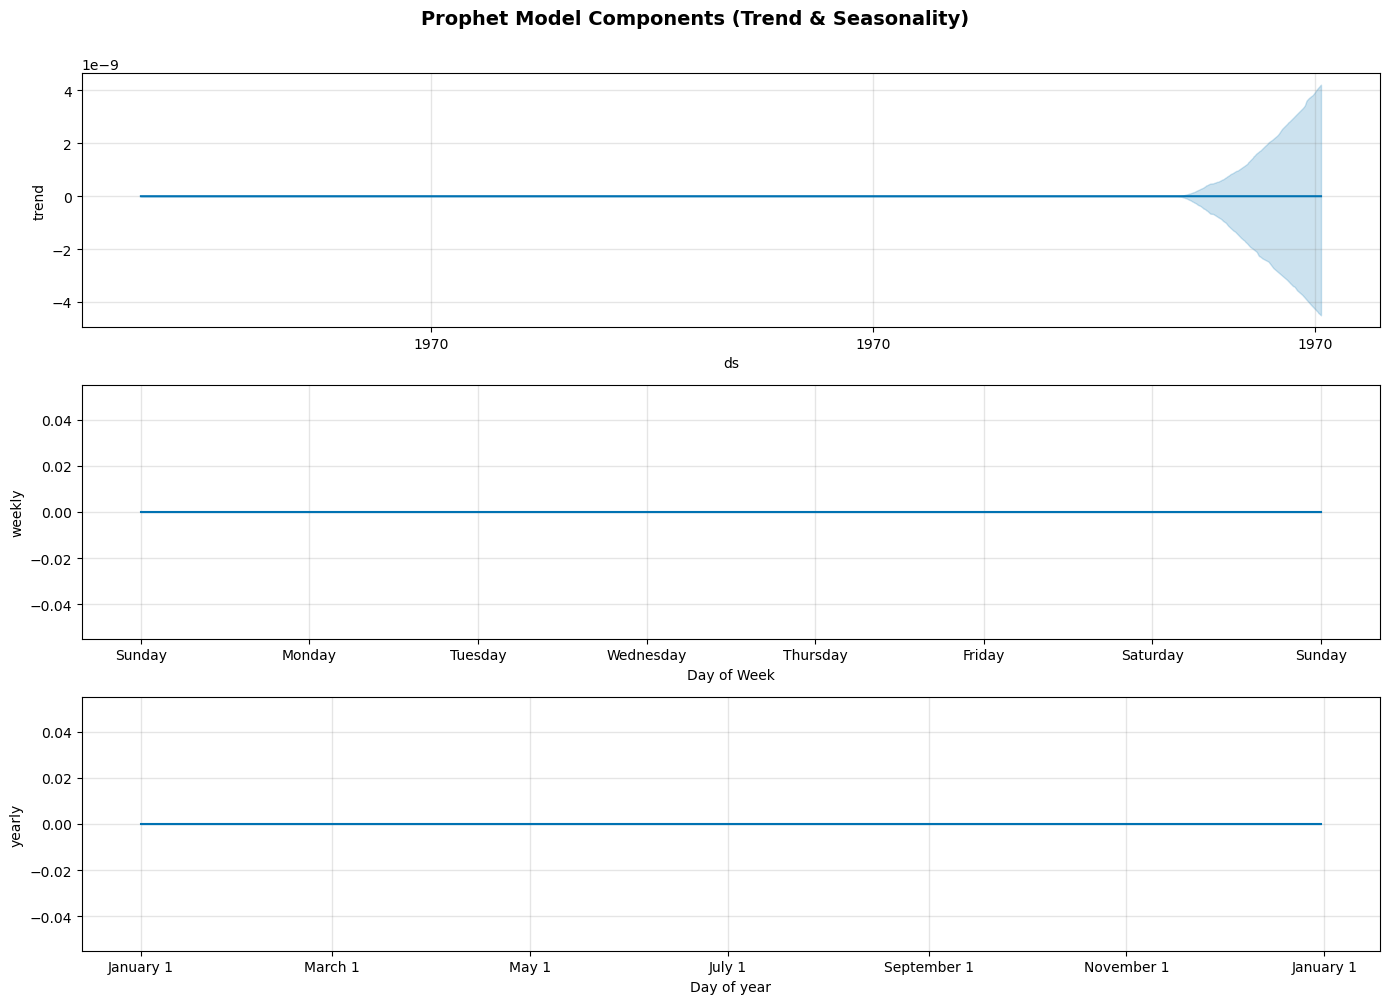


Component Analysis: The plots above show:
- Trend: Overall direction of the time series
- Yearly Seasonality: Patterns that repeat annually
- Weekly Seasonality: Patterns that repeat weekly


In [7]:
# Component analysis - visualize trend and seasonality
fig = model.plot_components(forecast, figsize=(14, 10))
plt.suptitle('Prophet Model Components (Trend & Seasonality)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\nComponent Analysis: The plots above show:")
print("- Trend: Overall direction of the time series")
print("- Yearly Seasonality: Patterns that repeat annually")
print("- Weekly Seasonality: Patterns that repeat weekly")

FUTURE FORECAST (Next 30 Days)
                           ds  yhat    yhat_lower    yhat_upper
1970-01-02 00:00:00.000279013   0.0   -554.510244    572.252424
1970-01-03 00:00:00.000279013   0.0  -1685.232134   1703.454014
1970-01-04 00:00:00.000279013   0.0  -3253.908454   3123.182806
1970-01-05 00:00:00.000279013   0.0  -5051.843055   4632.296500
1970-01-06 00:00:00.000279013   0.0  -6966.866638   6209.070595
1970-01-07 00:00:00.000279013   0.0  -8753.126461   8247.547265
1970-01-08 00:00:00.000279013   0.0 -10682.892722  10753.383901
1970-01-09 00:00:00.000279013   0.0 -13023.892546  12861.617987
1970-01-10 00:00:00.000279013   0.0 -15435.213346  15653.998593
1970-01-11 00:00:00.000279013   0.0 -18040.447463  18083.677455
1970-01-12 00:00:00.000279013   0.0 -20472.993579  21387.703323
1970-01-13 00:00:00.000279013   0.0 -22693.236249  24090.235007
1970-01-14 00:00:00.000279013   0.0 -26181.482739  27473.914797
1970-01-15 00:00:00.000279013   0.0 -28941.768280  30755.628596
1970-01-1

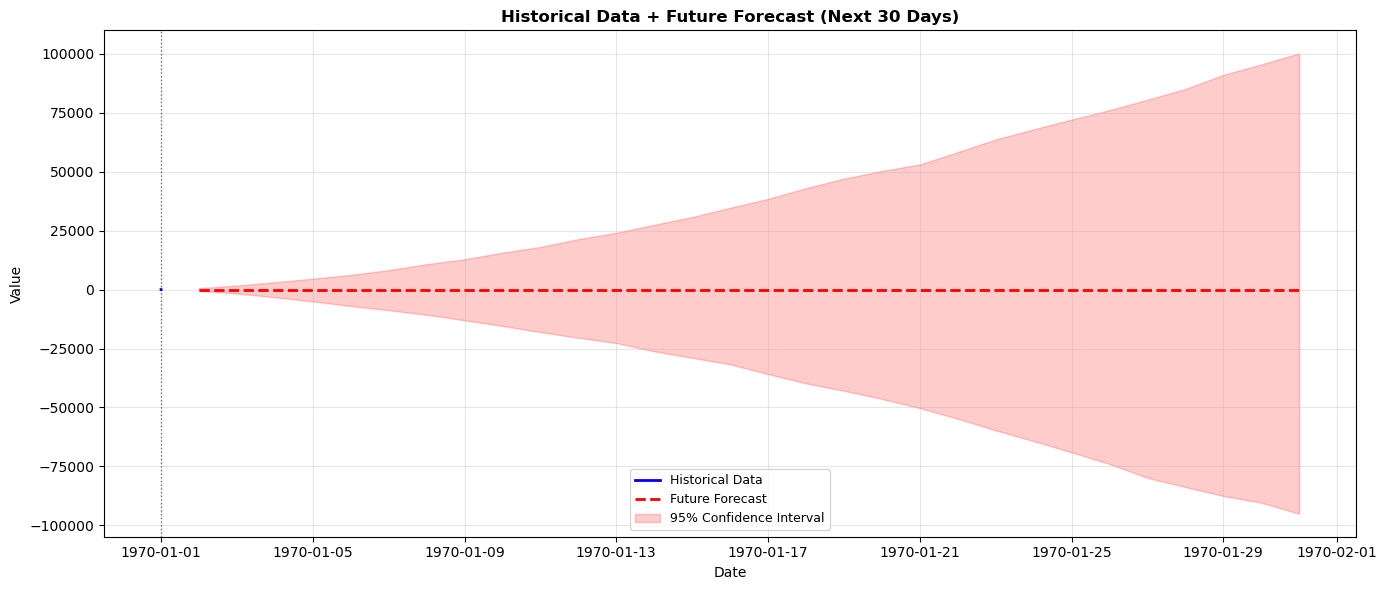

In [8]:
# Future forecasting - predict beyond historical data
# Create a dataframe for future dates (e.g., next 30 days)
from datetime import timedelta

last_date = prophet_df['ds'].max()
future_periods = 30  # Forecast for next 30 days

future_dates = pd.DataFrame({
    'ds': [last_date + timedelta(days=x) for x in range(1, future_periods + 1)]
})

# Make predictions for future
future_forecast = model.predict(future_dates)

# Display future predictions
print("=" * 60)
print("FUTURE FORECAST (Next 30 Days)")
print("=" * 60)
print(future_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_string(index=False))

# Plot historical data + future forecast
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(prophet_df['ds'], prophet_df['y'], label='Historical Data', color='blue', linewidth=2)
ax.plot(future_forecast['ds'], future_forecast['yhat'], label='Future Forecast', 
        color='red', linewidth=2, linestyle='--')
ax.fill_between(future_forecast['ds'], 
                 future_forecast['yhat_lower'], 
                 future_forecast['yhat_upper'], 
                 alpha=0.2, color='red', label='95% Confidence Interval')
ax.axvline(x=last_date, color='black', linestyle=':', linewidth=1, alpha=0.5)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Value', fontsize=10)
ax.set_title('Historical Data + Future Forecast (Next 30 Days)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()